In [1]:
import seaborn as sns
import swmpy as swm

This notebook examines the distributions of key variables - $B_H$ from SuperMAG data and OMNI solar wind parameters.  The distributions highlight that a small number of $B_H$ values are excessively large (e.g., on the order of a million nT).  These unrealistic values are removed from the data set used for machine learning.

Note, the histograms below were generated before the modification to the python code in utils.py.  Based on this journal, a statement was added to _merge_files to remove entries with a $B_H > 10000$ nT.  To replicate results, ensure that drop_large=True in the call to get_data_all below.

In [2]:
from os.path import join

######################################################################
# Generic information, such as paths to directories, for multiple runs
######################################################################

data_dir = r'/Volumes/PhysicsHD/swmpy/'

# "SuperMAG UserID" ==> UserID for SuperMAG website
# "years" ==> downloaded data will cover these years
# "numbers" ==> number of minutes over which statistics are calculated (e.g., 
#     number = 30 means 30-minute windows are used to determine the mean of solar 
#     wind and magnetometer data)
# "distances" ==> OMNI solar wind data is ballistically propagated to these 
#     distances from Earth (measured in Re)
# "SuperMAG Directory" ==> Directory for SuperMAG magnetometer data
# "Kp Directory" ==> Directory for Kp data
# "OMNI Directory" ==> Directory for OMNI solar wind data
# "FIT Directory" ==> Directory where autogluon fit results and plots will be stored

file_info = {
        "SuperMAG UserID": "USERNAME",
        "years": [2023,2024,2025,],
        "distances": [None, 10, 8, 6, 4, 2, 0], 
        "numbers":  [None, 5, 10, 15, 20, 25, 30,],
        "SuperMAG Directory": join(data_dir, "SuperMAG"),
        "OMNI Directory": join(data_dir, "OMNI"),
        "Kp Directory": join(data_dir, "Kp"),
        "Fit Directory": join(data_dir, "Fit_All"),
}

In [3]:
#################################################################
# Specific parameters for the this run
#################################################################

# "info" ==> "all" for all years and all stations, or "single" for one year, one station
# "uselogy" ==> True/False, use log of y for fit
# "standardize" ==> True/False, standardize data => (data-mean)/stddev
# "number" ==> number of minutes over which OMNI and SuperMAG data average, None if we want raw 1-minute cadence data
# "distance" ==> distance from Earth in Re that we ballistic propagate OMNI data to, None if we want raw OMNI data
# "Kp Lower" ==> keep OMNI/SuperMAG data for events with Kp above this, or None if keep all data
# "Kp Upper" ==> keep OMNI/SuperMAG data for events with Kp below this, or None if keep all data

run_info = {
    "info": 'all',  # all years, all stations
    "uselogy": False,
    "standardize": False,
    "number": 30,
    "distance": None,
    "Kp Lower": None,
    "Kp Upper": None,
    }

In [4]:
# Get the data for all stations, all years
train_set, test_set, scaler = swm.get_data_all( file_info, run_info, drop_large=False )

In [5]:
# The training set is large
train_set.shape

(6852208, 12)

In [6]:
# We have a small number of BH values that are extremely large.  We will isolate them by dropping all BH values below 10000.
import numpy as np
from copy import deepcopy

bh = deepcopy(train_set)
bh = bh.drop(bh[bh['B_H Mean'] <= 10000.].index)
bh

,"Bx, nT (GSE, GSM) Mean","Bz, nT (GSE) Mean","Vx Velocity, km/s, GSE Mean","Vy Velocity, km/s, GSE Mean","Vz Velocity, km/s, GSE Mean","Proton Density, n/cc Mean",B_H Mean,cosmlt,sinmlt,cosmcolat,sinmcolat,station
3191401,-4.843103,0.388276,-346.550000,13.193750,-58.043750,6.371250,1.414212e+06,0.781366,-0.624072,0.627008,0.779013,AAA
3191399,-5.976333,-0.506667,-358.968750,20.437500,-49.212500,7.745625,1.414212e+06,0.571950,-0.820288,0.627008,0.779013,AAA
3191413,-4.618667,5.759333,-354.788000,-8.980000,-15.548000,12.195200,1.414212e+06,0.580135,0.814520,0.627008,0.779013,AAA
3191411,-5.431667,6.134000,-358.223077,-6.315385,-12.053846,9.360769,1.414212e+06,0.768180,0.640234,0.627008,0.779013,AAA
3191404,-4.893103,0.698276,-367.377273,-11.950000,-52.831818,6.101364,1.225652e+06,0.974734,-0.223369,0.627008,0.779013,AAA
4208159,2.222000,0.072667,-321.540000,-25.090000,-3.183333,7.742667,2.828774e+05,-0.782450,-0.622713,0.415695,0.909504,KAG
3191414,-5.081000,5.968000,-353.929167,-16.045833,-21.079167,9.297083,1.414212e+06,0.470427,0.882439,0.627008,0.779013,AAA
5585063,-3.297586,-1.686552,-373.439130,-25.643478,-1.660870,2.453043,9.428463e+05,-0.845723,0.533622,0.020482,0.999790,Y12
5585064,-3.062333,-1.516667,-370.940000,-27.336000,-1.888000,2.358800,2.357818e+05,-0.904687,0.426078,0.020482,0.999790,Y12
3191415,-4.751034,6.312759,-349.794444,-22.138889,-18.455556,7.203333,1.414212e+06,0.352534,0.935799,0.627008,0.779013,AAA


In [7]:
# We have 20 extremely large BH values (>10,000 nT). As seen above, the points are predominantly from one station, and most are on 
# the order of 1 million nT.
len(bh)

20

In [8]:
# Using a cut-off of 5000 nT rather than 10,000 nT does not change the number of points dropped.
# This provides further evidence that the >10,000 nT values are anomalous, and can be discarded.
bh2 = deepcopy(train_set)
bh2 = bh2.drop(bh2[bh2['B_H Mean'] <= 5000.].index)
bh2

,"Bx, nT (GSE, GSM) Mean","Bz, nT (GSE) Mean","Vx Velocity, km/s, GSE Mean","Vy Velocity, km/s, GSE Mean","Vz Velocity, km/s, GSE Mean","Proton Density, n/cc Mean",B_H Mean,cosmlt,sinmlt,cosmcolat,sinmcolat,station
3191401,-4.843103,0.388276,-346.550000,13.193750,-58.043750,6.371250,1.414212e+06,0.781366,-0.624072,0.627008,0.779013,AAA
3191399,-5.976333,-0.506667,-358.968750,20.437500,-49.212500,7.745625,1.414212e+06,0.571950,-0.820288,0.627008,0.779013,AAA
3191413,-4.618667,5.759333,-354.788000,-8.980000,-15.548000,12.195200,1.414212e+06,0.580135,0.814520,0.627008,0.779013,AAA
3191411,-5.431667,6.134000,-358.223077,-6.315385,-12.053846,9.360769,1.414212e+06,0.768180,0.640234,0.627008,0.779013,AAA
3191404,-4.893103,0.698276,-367.377273,-11.950000,-52.831818,6.101364,1.225652e+06,0.974734,-0.223369,0.627008,0.779013,AAA
4208159,2.222000,0.072667,-321.540000,-25.090000,-3.183333,7.742667,2.828774e+05,-0.782450,-0.622713,0.415695,0.909504,KAG
3191414,-5.081000,5.968000,-353.929167,-16.045833,-21.079167,9.297083,1.414212e+06,0.470427,0.882439,0.627008,0.779013,AAA
5585063,-3.297586,-1.686552,-373.439130,-25.643478,-1.660870,2.453043,9.428463e+05,-0.845723,0.533622,0.020482,0.999790,Y12
5585064,-3.062333,-1.516667,-370.940000,-27.336000,-1.888000,2.358800,2.357818e+05,-0.904687,0.426078,0.020482,0.999790,Y12
3191415,-4.751034,6.312759,-349.794444,-22.138889,-18.455556,7.203333,1.414212e+06,0.352534,0.935799,0.627008,0.779013,AAA


In [9]:
# Number of large BH values (>5000) is unchanged from the threshold of 10,000 nT
len(bh2)

20

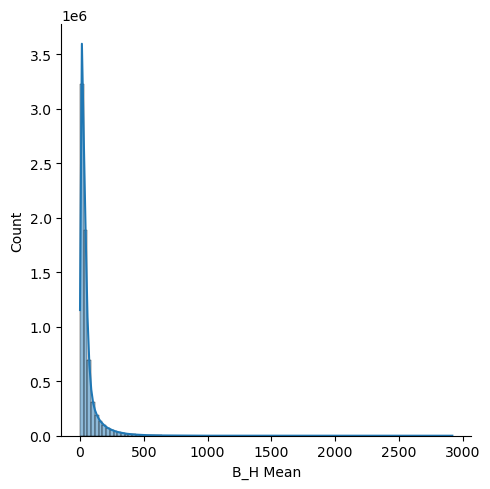

In [10]:
# Let's look at the distribution of points below 10,000 nT, the points that we'll keep for our analysis.
# The distribution has a very long tail that is likely to affect the statistical analysis.
bh_keep = deepcopy(train_set)
bh_keep = bh_keep.drop(bh_keep[bh_keep['B_H Mean'] > 10000.].index)
sns.displot(bh_keep['B_H Mean'], kde=True, bins=100)

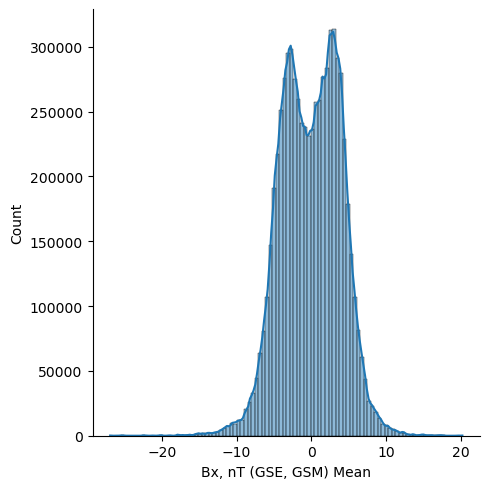

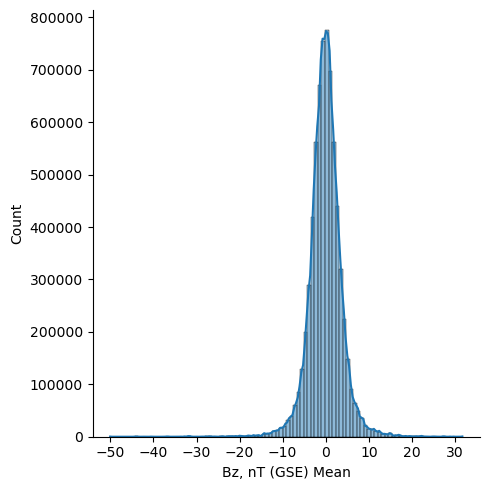

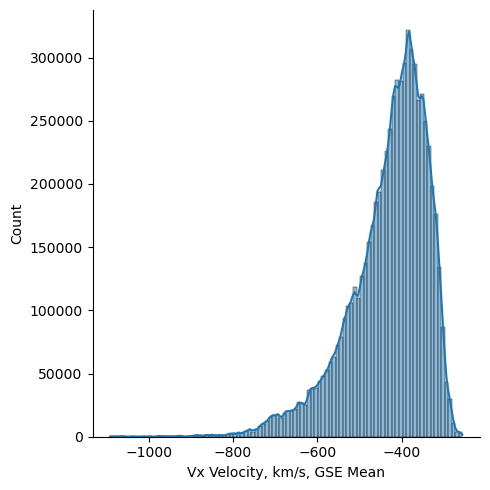

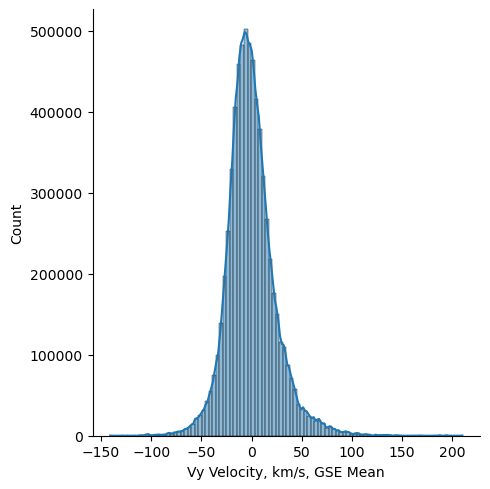

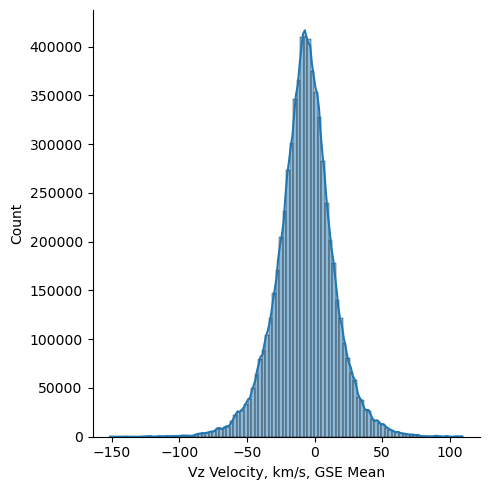

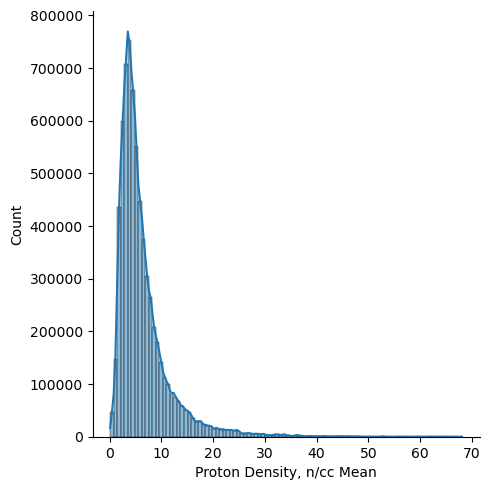

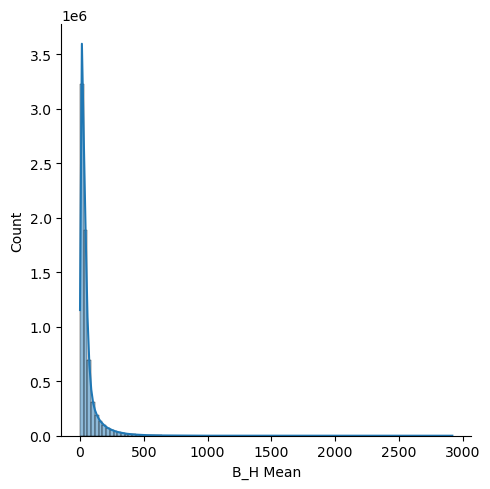

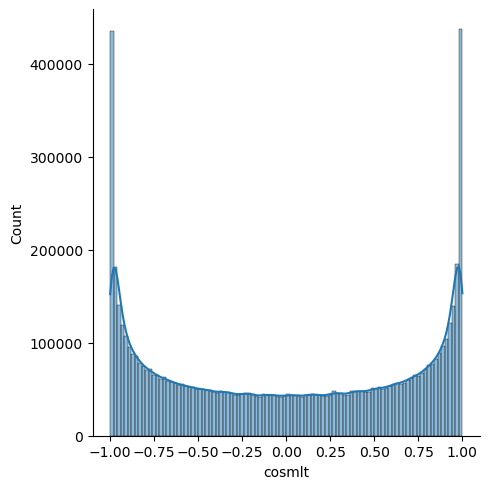

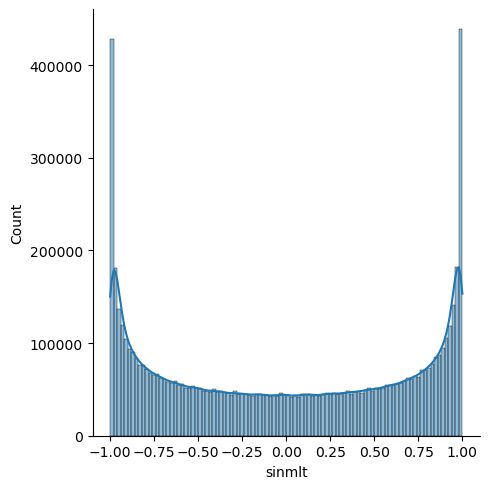

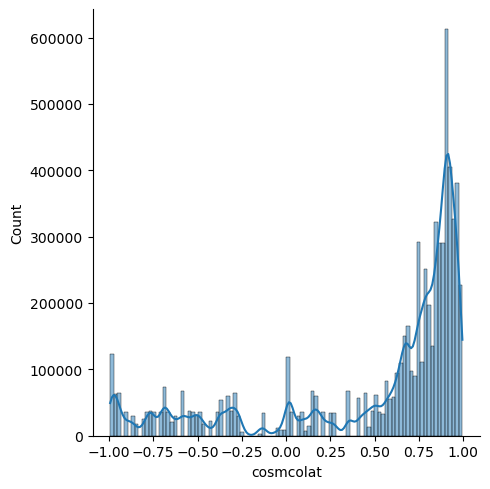

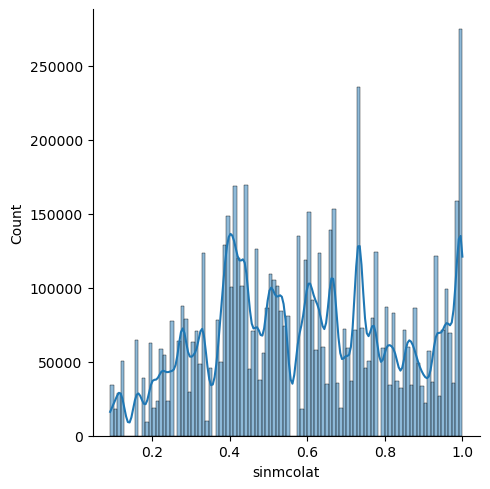

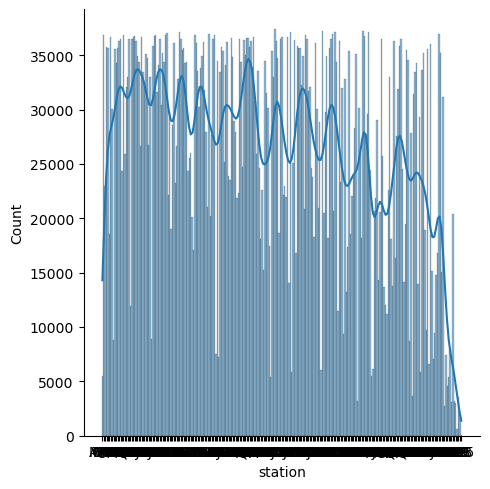

In [11]:
# The other parameters in the fit do not have characteristics that raise any immediate concerns.
names = bh_keep.columns

for i, name in enumerate(names):
    sns.displot(bh_keep[name], kde=True, bins=100)

In [12]:
# We dropped only 20 points from the training set, which originally had 6,852,208 data points
len(train_set)-len(bh_keep)

20

In [13]:
# The max BH value is below 3000 nT
bh_keep['B_H Mean'].max()

2919.3752803491952

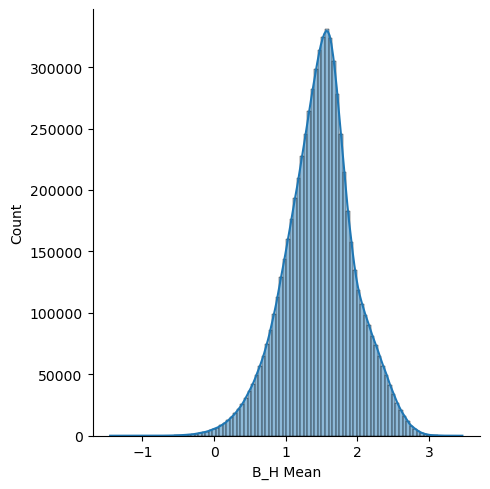

In [14]:
# In our fits, we will use log(BH), so let's look at its distribution
import numpy as np 
logBH = np.log10( bh_keep['B_H Mean'] )
sns.displot(logBH, kde=True, bins=100)